# Testing Classification on Sphere vs Ellipsoid to see how much stretching is needed to differentiate.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import ecc_vr as vr 

from Sphere_Ellipsoid_Utils import unif_hypersphere, unif_hyperellipsoid, unit_ball_volume, scale_axes_target_volume, edge_count_curve, simulate_edge_curves

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# What the function below does...

This function  sphere_vs_ellipsoid_edge_curve_classifier  simulates points clouds from a sphere and an ellipsoid, converts each point cloud into an edge count curve over a grid of threshold values t, train a logistic-regression classifierto distinguish the two shapes from those curves, and returns the fitted model plus summary results.

### Step by Step

1. Sets the threshold grid t_grid. If t_grid is None, it uses np.linspace(0.5,5,30). Otherwise, it converts input into a numpy array of floats.

2. Determines ellipsoid stretch values. If ellipsoid_stretch is None, it creates a default ellipsoid: ellipsoid_stretch = [1.5, 1.0, 1.0, ..., 1.0] with length ambient_dim, or length 3 if ambient_dim was also None.

3. If you do pass ellipsoid_stretch, it converts it to a NumPy float array.

4. It overwrites the input argument target_volume with unit_ball_volume(ambient_dim) * np.prod(ellipsoid_stretch). 

5. That new target_volume is the volume of an ambient_dim-dimensional ellipsoid whose semi-axis lengths are given by ellipsoid_stretch.

7. It computes a sphere radius sphere_radius = (target_volume / unit_ball_volume(ambient_dim)) ** (1 / ambient_dim),so the sphere has the same volume as that ellipsoid.

8. Sets ellipsoid_axes = scale_axes_target_volume(ellipsoid_stretch, target_volume). Because target_volume was defined from ellipsoid_stretch just above, this step is usually effectively a no-op, so ellipsoid_axes will normally be the same as ellipsoid_stretch up to possible floating-point noise.

9. It simulates n_resamples sphere point clouds using unif_hypersphere(...). Each sphere sample has: n_points points, ambient dimension ambient_dim, radius sphere_radius.

10. For each sphere sample, simulate_edge_curves(...) computes its edge-count curve across all values in t_grid. So curves_sphere is a matrix of shape (n_resamples, len(t_grid)).

11. Simulates n_resamples ellipsoid point clouds using unif_hyperellipsoid(n_points, *ellipsoid_axes, seed=s).

12. For each ellipsoid sample, it again computes the edge-count curve across t_grid. So curves_ellipsoid is also a matrix of shape (n_resamples, len(t_grid)).

13. Stacks the two curve matrices into one feature matrix: X = np.vstack([curves_sphere, curves_ellipsoid]).

14. Builds a label vector: 0 for every sphere curve,1 for every ellipsoid curve.

15. Splits the data into training and test sets using train_test_split(...). The stratify=y argument keeps the class balance the same in both sets.

16. Builds a classification pipeline: StandardScaler() standardizes each curve feature, LogisticRegression(max_iter=5000) fits a linear classifier.

17. Fits the classifier on the training data.

18. Predicts labels on the test data.

19. Returns a dictionary containing:
    "shape1" and "shape2": the names "sphere" and "ellipsoid"
    "ambient_dim": the ambient dimension used
    "target_volume": the overwritten volume value based on ellipsoid_stretch
    "sphere_radius": the radius chosen so the sphere matches that volume
    "ellipsoid_stretch_input": your ellipsoid stretch as a NumPy array
    "ellipsoid_axes": the axes actually used for ellipsoid sampling
    "t_grid": the threshold grid
    "curves1" and "curves_sphere": the sphere edge-count curves
    "curves2" and "curves_ellipsoid": the ellipsoid edge-count curves
    "classifier": the fitted pipeline
    "accuracy": test-set classification accuracy
    "report": the classification report
    "X_test", "y_test", "y_pred": test features, true labels, and predicted labels

### Important notes

- The input argument target_volume is not actually used as an input; it gets replaced inside the function.
- The intended geometric idea is: sphere volume = ellipsoid volume,then compare the two shapes using edge-count curves from repeated random samples.

In [3]:
def sphere_vs_ellipsoid_edge_curve_classifier(
        n_points: int = 100,
        t_grid: np.ndarray | None = None,
        n_resamples: int = 300,
        ambient_dim: int | None = None,
        ellipsoid_stretch: np.ndarray | list | tuple | None = None,
        target_volume: float = 1.0,
        seed1: int = 42,
        seed2: int = 43,
        test_size: float = 0.25,
        random_state: int = 0,
):  
    
    if t_grid is None:
        t_grid = np.linspace(0.5, 5, 30)
    else:
        t_grid = np.asarray(t_grid, dtype = float)

    if ellipsoid_stretch is None:
        ambient_dim = 3 if ambient_dim is None else ambient_dim
        ellipsoid_stretch = np.ones(ambient_dim, dtype = float)
        ellipsoid_stretch[0] = 1.5
    else:
        ellipsoid_stretch = np.asarray(ellipsoid_stretch, dtype = float)
        if ambient_dim is None:
            ambient_dim = ellipsoid_stretch.size
            raise ValueError("ambient_dim must match len(ellipsoid_stretch).")
    
    target_volume = unit_ball_volume(ambient_dim) * np.prod(ellipsoid_stretch)
    
    sphere_radius = (target_volume / unit_ball_volume(ambient_dim)) ** ( 1.0 / ambient_dim)
    ellipsoid_axes = scale_axes_target_volume(ellipsoid_stretch, target_volume)

    curves_sphere = simulate_edge_curves(
        point_cloud_sampler = lambda s: unif_hypersphere(
            n_points = n_points,
            d = ambient_dim,
            r = sphere_radius,
            seed = s,
        ),
        n_resamples=n_resamples,
        t_grid=t_grid,
        seed = seed1,
    )
    
    curves_ellipsoid = simulate_edge_curves(
        point_cloud_sampler=lambda s: unif_hyperellipsoid(
            n_points,
            *ellipsoid_axes,
            seed = s,
        ),
        n_resamples=n_resamples,
        t_grid=t_grid,
        seed=seed2,
    )

    X = np.vstack([curves_sphere, curves_ellipsoid])
    y = np.array([0] * len(curves_sphere) + [1] * len(curves_ellipsoid))

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size = test_size,
        random_state=random_state,
        stratify=y
    )

    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter = 5000),
    )

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    return {
        "shape1": "sphere",
        "shape2": "ellipsoid",
        "ambient_dim": ambient_dim,
        "target_volume": target_volume,
        "sphere_radius": sphere_radius,
        "ellipsoid_stretch_input": np.asarray(ellipsoid_stretch, dtype = float),
        "ellipsoid_axes": ellipsoid_axes,
        "t_grid": t_grid,
        "curves1": curves_sphere,
        "curves2": curves_ellipsoid,
        "curves_sphere": curves_sphere,
        "curves_ellipsoid": curves_ellipsoid,
        "classifier": clf,
        "accuracy": accuracy_score(y_test, y_pred),
        "report": classification_report(
            y_test,
            y_pred,
            target_names=["Sphere", "Ellipsoid"],
            zero_division=0,
        ),
        "X_test": X_test,
        "y_test": y_test,
        "y_pred": y_pred,
    }

In [4]:
def plot_sphere_ellipsoid_results(result):
    t_grid = result["t_grid"]
    curves_sphere = result["curves_sphere"]
    curves_ellipsoid = result["curves_ellipsoid"]

    mean1 = curves_sphere.mean(axis=0)
    sd1 = curves_sphere.std(axis = 0, ddof = 1)

    mean2 = curves_ellipsoid.mean(axis = 0)
    sd2 = curves_ellipsoid.std(axis =0, ddof = 1)

    fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

    ax[0].plot(t_grid, mean1, lw = 2, label = "Sphere Edge Count Simulation Mean")
    ax[0].fill_between(t_grid, mean1 - sd1, mean1 + sd1, alpha = 0.2)

    ax[0].plot(t_grid, mean2, lw = 2, label = "Ellipsoid Edge Count Simulation Mean")
    ax[0].fill_between(t_grid, mean2 - sd2, mean2 + sd2, alpha = 0.2)

    ax[0].set_xlabel("t")
    ax[0].set_ylabel("Edge Count")
    ax[0].set_title("Edge Count Curves")
    ax[0].legend()

    ConfusionMatrixDisplay.from_predictions(
        result["y_test"],
        result["y_pred"],
        display_labels=["Sphere", "Ellipsoid"],
        cmap = "Blues",
        ax=ax[1],
    )
    ax[1].set_title("Classifier Confusion Matrix")

    plt.tight_layout()
    plt.show()

    print("Accuracy:", result["accuracy"])
    print(result["report"])

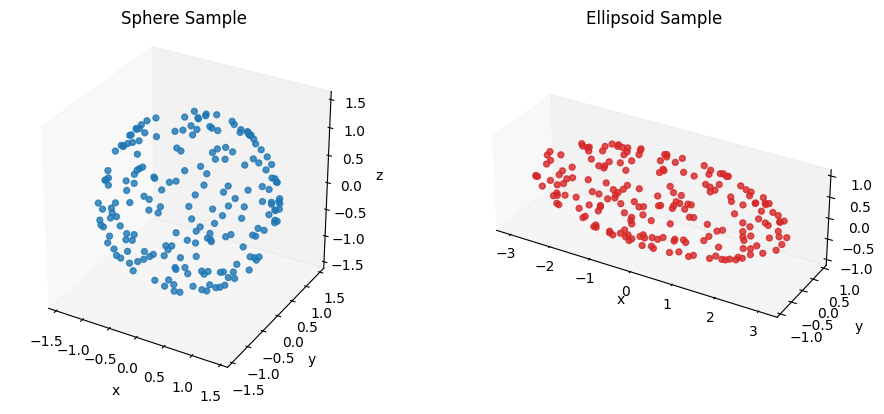

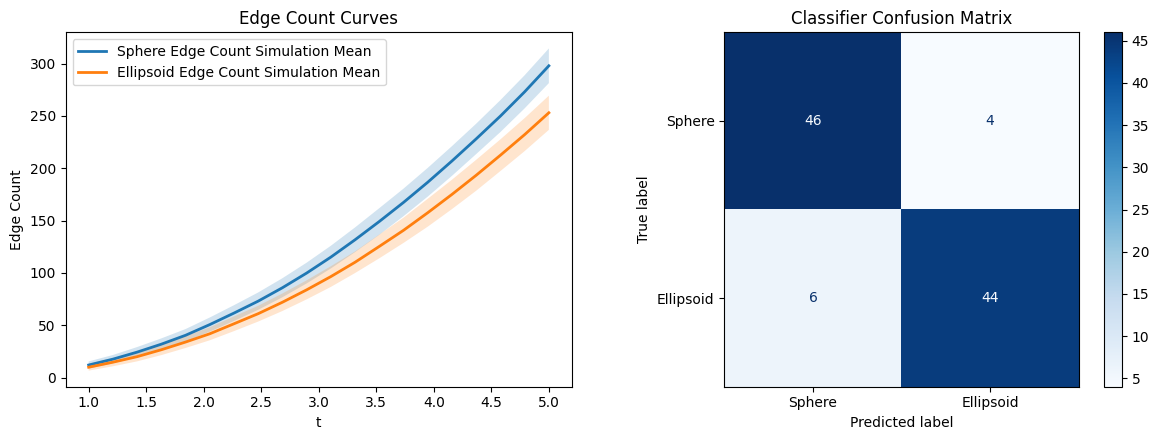

Accuracy: 0.9
              precision    recall  f1-score   support

      Sphere       0.88      0.92      0.90        50
   Ellipsoid       0.92      0.88      0.90        50

    accuracy                           0.90       100
   macro avg       0.90      0.90      0.90       100
weighted avg       0.90      0.90      0.90       100



In [14]:
plt.style.use("default")

# INPUT
n_points = 200
n_resamples = 200
ambient_dim = 3
t_grid = np.linspace(1,5,20)

ellipsoid_stretch = [3.0, 1.0, 1.0]

result = sphere_vs_ellipsoid_edge_curve_classifier(
    ambient_dim=ambient_dim,
    n_points=n_points,
    n_resamples=n_resamples,
    t_grid=t_grid,
    ellipsoid_stretch=ellipsoid_stretch,
)

fig = plt.figure(figsize=(10, 4))

samples = [
    ("Sphere", unif_hypersphere(n_points, result["ambient_dim"], r = result["sphere_radius"], seed = 123), "tab:blue"),
    ("Ellipsoid", unif_hyperellipsoid(n_points, result["ellipsoid_axes"], seed = 456), "tab:red"),
]

for i, (shape, X, color) in enumerate(samples, start = 1):
    projected = X.shape[1] > 3
    if projected:
        X = vr.pca_project(X, out_dim = 2)
    
    d = X.shape[1]
    ax = fig.add_subplot(1, 2, i, projection="3d" if d == 3 else None)

    if d == 3:
        ax.scatter(X[:, 0], X[:, 1], X[:, 2], s = 18, alpha = 0.8, color=color)
        ax.set_aspect("equal")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_zlabel("z")
    elif d == 2:
        ax.scatter(X[:, 0], X[:, 1], s=18, alpha=0.8, color=color)
        ax.set_aspect("equal")
        ax.set_xlabel("PC1" if projected else "x")
        ax.set_ylabel("PC2" if projected else "y")
    else:
        ax.scatter(X[:, 0], np.zeros(len(X)), s=18, alpha=0.8, color=color)
        ax.set_xlabel("x")
        ax.set_ylabel("")

    ax.set_title(f"{shape} Sample")
    ax.grid(False)

plt.tight_layout()
plt.show()

plot_sphere_ellipsoid_results(result)


# Let's sweep on one axis stretch.

The main idea is to test the sphere vs ellipsoid with axes [s,1,1].

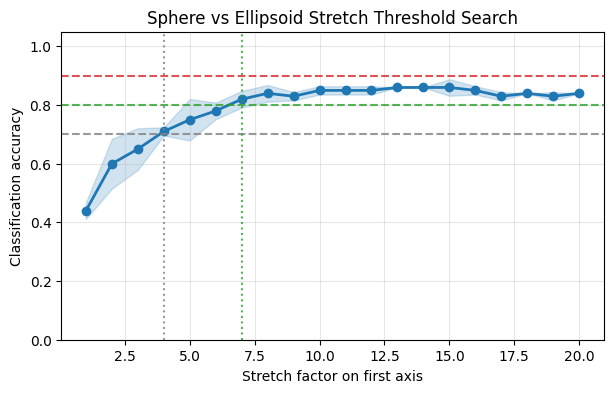

Smallest tested stretch reaching 70% accuracy: 4.000
Smallest tested stretch reaching 80% accuracy: 7.000
No tested stretch reached 90% accuracy.
stretch=1.000   mean_acc=0.440   sd=0.028
stretch=2.000   mean_acc=0.600   sd=0.085
stretch=3.000   mean_acc=0.650   sd=0.071
stretch=4.000   mean_acc=0.710   sd=0.014
stretch=5.000   mean_acc=0.750   sd=0.071
stretch=6.000   mean_acc=0.780   sd=0.028
stretch=7.000   mean_acc=0.820   sd=0.028
stretch=8.000   mean_acc=0.840   sd=0.028
stretch=9.000   mean_acc=0.830   sd=0.014
stretch=10.000   mean_acc=0.850   sd=0.014
stretch=11.000   mean_acc=0.850   sd=0.014
stretch=12.000   mean_acc=0.850   sd=0.014
stretch=13.000   mean_acc=0.860   sd=0.000
stretch=14.000   mean_acc=0.860   sd=0.000
stretch=15.000   mean_acc=0.860   sd=0.028
stretch=16.000   mean_acc=0.850   sd=0.014
stretch=17.000   mean_acc=0.830   sd=0.014
stretch=18.000   mean_acc=0.840   sd=0.000
stretch=19.000   mean_acc=0.830   sd=0.014
stretch=20.000   mean_acc=0.840   sd=0.000


In [6]:
def find_stretch_thresholds(
    ambient_dim=3,
    n_points=100,
    n_resamples=100,
    t_grid=None,
    stretch_min=1.0,
    stretch_max=5.0,
    n_stretches=21,
    n_repeats=10,
    targets=(0.80, 0.90, 0.95),
):
    if t_grid is None:
        t_grid = np.linspace(0.5, 3.0, 15)

    stretch_values = np.linspace(stretch_min, stretch_max, n_stretches)
    mean_acc = []
    sd_acc = []
    all_acc = []

    for s in stretch_values:
        run_acc = []

        for r in range(n_repeats):
            ellipsoid_stretch = np.array([s, 1.0, 1.0], dtype=float)

            if ambient_dim == 2:
                ellipsoid_stretch = ellipsoid_stretch[:2]
            elif ambient_dim > 3:
                ellipsoid_stretch = np.concatenate(
                    [ellipsoid_stretch, np.ones(ambient_dim - 3)]
                )

            result = sphere_vs_ellipsoid_edge_curve_classifier(
                ambient_dim=ambient_dim,
                n_points=n_points,
                n_resamples=n_resamples,
                t_grid=t_grid,
                ellipsoid_stretch=ellipsoid_stretch,
                seed1=1000 + r,
                seed2=2000 + r,
                random_state=r,
            )

            run_acc.append(result["accuracy"])

        run_acc = np.array(run_acc, dtype=float)
        all_acc.append(run_acc)
        mean_acc.append(run_acc.mean())
        sd_acc.append(run_acc.std(ddof=1))

    mean_acc = np.array(mean_acc)
    sd_acc = np.array(sd_acc)

    thresholds = {}
    for target in targets:
        good = np.where(mean_acc >= target)[0]
        thresholds[target] = None if len(good) == 0 else stretch_values[good[0]]

    return {
        "stretch_values": stretch_values,
        "mean_acc": mean_acc,
        "sd_acc": sd_acc,
        "all_acc": all_acc,
        "thresholds": thresholds,
        "targets": tuple(targets),
        "ambient_dim": ambient_dim,
        "n_points": n_points,
        "n_resamples": n_resamples,
        "n_repeats": n_repeats,
        "t_grid": np.asarray(t_grid, dtype=float),
    }

def plot_stretch_threshold_search(summary):
    stretch_values = summary["stretch_values"]
    mean_acc = summary["mean_acc"]
    sd_acc = summary["sd_acc"]
    thresholds = summary["thresholds"]

    plt.style.use("default")
    plt.figure(figsize=(7, 4))

    plt.plot(stretch_values, mean_acc, marker="o", lw=2, color="tab:blue")
    plt.fill_between(
        stretch_values,
        mean_acc - sd_acc,
        mean_acc + sd_acc,
        alpha=0.2,
        color="tab:blue",
    )

    colors = {0.80: "tab:green", 0.90: "tab:red", 0.95: "tab:orange"}

    for target, stretch in thresholds.items():
        plt.axhline(target, ls="--", color=colors.get(target, "gray"), alpha=0.8)
        if stretch is not None:
            plt.axvline(stretch, ls=":", color=colors.get(target, "gray"), alpha=0.8)

    plt.xlabel("Stretch factor on first axis")
    plt.ylabel("Classification accuracy")
    plt.title("Sphere vs Ellipsoid Stretch Threshold Search")
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.show()

    for target, stretch in thresholds.items():
        if stretch is None:
            print(f"No tested stretch reached {target:.0%} accuracy.")
        else:
            print(f"Smallest tested stretch reaching {target:.0%} accuracy: {stretch:.3f}")


summary = find_stretch_thresholds(
    ambient_dim=2,
    n_points=100,
    n_resamples=100,
    t_grid=np.linspace(1, 2, 10),
    stretch_min=1.0,
    stretch_max=20.0,
    n_stretches=20,
    n_repeats=2,
    targets=(0.70, 0.80, 0.90),
)

plot_stretch_threshold_search(summary)

for s, m, sd in zip(summary["stretch_values"], summary["mean_acc"], summary["sd_acc"]):
    print(f"stretch={s:.3f}   mean_acc={m:.3f}   sd={sd:.3f}")


The code below studies how different ways of stretching an ellipsoid affect how well our classifiercan distinguish it from a sphere.

### The Idea

For each stretch pattern and each stretch value `s`, the code:

1. builds an ellipsoid with axes determined by that pattern
2. runs the classifier
3. records classifier accuracy
4. repeats experiment multiple times with different random seeds
5. averages the accuracies
6. plots mean accuracy scores

## What `compare_stretch_patterns` does

### Inputs

1. `patterns`
A dictionary mapping a pattern label to a function that builds ellipsoid axis lengths form `s` and `ambiend_dim`.

2. `stretch_values`
The values of stretch parameter `s` to test.

3. `ambient_dim`

4. `n_points`

5. `n_resamples`

6. `t_grid`

7. `n_repeats`
Number of repeated classifier runs for each stretch value.

### Now what

For each stretch pattern:

1. Loop over every stretch value `s`
2. For each `s`, repeat the classification experiment `n_repeats` times
3. Each time, it creates `ellipsoid_stretch` using chosen pattern
4. Checks that axis vector has correct length `ambient_dim`
5. Runs classifier
6. Stores accuracy

After repeating the run several times for the same `s`, it computes:

- mean_acc: average classification accuracy
- sd_acc: standard deviation of classification accuracy
- all_acc: raw repeated accuracies

It stores these for every pattern and returns a dictionary `results` with:

- stretch values tested
- results for each pattern
- experiment settings

## Stretch Patterns Used Here

### In 2D

- `"[s, 1]"`
  stretches one axis only

- `"[s, s]"`
  stretches both axes equally

- `"[s, 1/s]"`
  stretches one axis while shrinking the other

### In 3D

- `"[s, 1, 1]"`
  stretches one axis only

- `"[s, s, 1]"`
  stretches two axes equally

- `"[s, 1/s, 1]"`
  stretches one axis while shrinking another

### In dimensions above 3

The labels use `...` to indicate the remaining axes stay equal to `1`.

For example:

- `"[s, 1, 1, ..., 1]"`
- `"[s, s, 1, ..., 1]"`
- `"[s, 1/s, 1, ..., 1]"`



In [7]:
def compare_stretch_patterns(
    patterns,
    stretch_values,
    ambient_dim=3,
    n_points=100,
    n_resamples=100,
    t_grid=None,
    n_repeats=5,
):
    if t_grid is None:
        t_grid = np.linspace(0.5, 3.0, 15)
    else:
        t_grid = np.asarray(t_grid, dtype=float)

    stretch_values = np.asarray(stretch_values, dtype=float)
    summary = {}

    for name, pattern_fn in patterns.items():
        mean_acc = []
        sd_acc = []
        all_acc = []

        for s in stretch_values:
            run_acc = []

            for r in range(n_repeats):
                ellipsoid_stretch = np.asarray(pattern_fn(s, ambient_dim), dtype=float)

                if ellipsoid_stretch.shape != (ambient_dim,):
                    raise ValueError(
                        f"Pattern {name!r} returned shape {ellipsoid_stretch.shape}, expected {(ambient_dim,)}"
                    )

                result = sphere_vs_ellipsoid_edge_curve_classifier(
                    ambient_dim=ambient_dim,
                    n_points=n_points,
                    n_resamples=n_resamples,
                    t_grid=t_grid,
                    ellipsoid_stretch=ellipsoid_stretch,
                    seed1=1000 + r,
                    seed2=2000 + r,
                    random_state=r,
                )

                run_acc.append(result["accuracy"])

            run_acc = np.asarray(run_acc, dtype=float)
            all_acc.append(run_acc)
            mean_acc.append(run_acc.mean())
            sd_acc.append(run_acc.std(ddof=1) if len(run_acc) > 1 else 0.0)

        summary[name] = {
            "mean_acc": np.asarray(mean_acc, dtype=float),
            "sd_acc": np.asarray(sd_acc, dtype=float),
            "all_acc": all_acc,
        }

    return {
        "patterns": patterns,
        "stretch_values": stretch_values,
        "summary": summary,
        "ambient_dim": ambient_dim,
        "n_points": n_points,
        "n_resamples": n_resamples,
        "n_repeats": n_repeats,
        "t_grid": t_grid,
    }

def plot_stretch_pattern_comparison(results, accuracy_target=None):
    stretch_values = results["stretch_values"]
    summary = results["summary"]
    ambient_dim = results["ambient_dim"]

    plt.style.use("default")
    plt.figure(figsize=(8, 5))

    for name, vals in summary.items():
        mean_acc = vals["mean_acc"]
        sd_acc = vals["sd_acc"]

        plt.plot(stretch_values, mean_acc, marker="o", lw=2, label=name)
        plt.fill_between(
            stretch_values,
            mean_acc - sd_acc,
            mean_acc + sd_acc,
            alpha=0.15,
        )

    if accuracy_target is not None:
        plt.axhline(
            accuracy_target,
            ls="--",
            color="tab:red",
            label=f"{accuracy_target:.0%} target",
        )

    plt.xlabel("Stretch parameter s")
    plt.ylabel("Classification accuracy")
    plt.title(f"Sphere vs Ellipsoid: Stretch Pattern Comparison in {ambient_dim}D")
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    for name, vals in summary.items():
        mean_acc = vals["mean_acc"]
        sd_acc = vals["sd_acc"]

        print(name)
        for s, acc, sd in zip(stretch_values, mean_acc, sd_acc):
            print(f"  s={s:.3f}   mean_acc={acc:.3f}   sd={sd:.3f}")

        if accuracy_target is not None:
            good = np.where(mean_acc >= accuracy_target)[0]
            if len(good) > 0:
                print(f"  first stretch reaching {accuracy_target:.0%}: {stretch_values[good[0]]:.3f}")
            else:
                print(f"  no tested stretch reached {accuracy_target:.0%}")

        print()
        

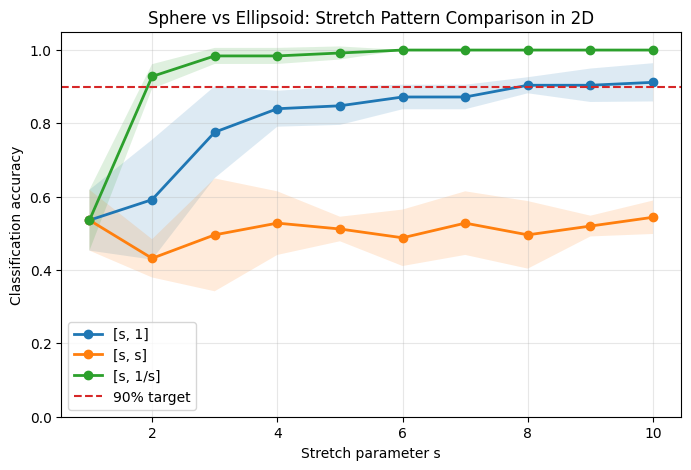

[s, 1]
  s=1.000   mean_acc=0.536   sd=0.083
  s=2.000   mean_acc=0.592   sd=0.163
  s=3.000   mean_acc=0.776   sd=0.125
  s=4.000   mean_acc=0.840   sd=0.049
  s=5.000   mean_acc=0.848   sd=0.052
  s=6.000   mean_acc=0.872   sd=0.033
  s=7.000   mean_acc=0.872   sd=0.033
  s=8.000   mean_acc=0.904   sd=0.022
  s=9.000   mean_acc=0.904   sd=0.046
  s=10.000   mean_acc=0.912   sd=0.052
  first stretch reaching 90%: 8.000

[s, s]
  s=1.000   mean_acc=0.536   sd=0.083
  s=2.000   mean_acc=0.432   sd=0.052
  s=3.000   mean_acc=0.496   sd=0.154
  s=4.000   mean_acc=0.528   sd=0.087
  s=5.000   mean_acc=0.512   sd=0.033
  s=6.000   mean_acc=0.488   sd=0.077
  s=7.000   mean_acc=0.528   sd=0.087
  s=8.000   mean_acc=0.496   sd=0.092
  s=9.000   mean_acc=0.520   sd=0.028
  s=10.000   mean_acc=0.544   sd=0.046
  no tested stretch reached 90%

[s, 1/s]
  s=1.000   mean_acc=0.536   sd=0.083
  s=2.000   mean_acc=0.928   sd=0.033
  s=3.000   mean_acc=0.984   sd=0.022
  s=4.000   mean_acc=0.984   sd

In [8]:
ambient_dim = 2
stretch_values = np.linspace(1.0, 10.0, 10)

if ambient_dim == 2:
    patterns = {
        "[s, 1]": lambda s, d: [s] + [1.0] * (d - 1),
        "[s, s]": lambda s, d: [s, s] + [1.0] * (d - 2),
        "[s, 1/s]": lambda s, d: [s, 1.0 / s] + [1.0] * (d - 2),
    }
elif ambient_dim == 3:
    patterns = {
        "[s, 1, 1]": lambda s, d: [s] + [1.0] * (d - 1),
        "[s, s, 1]": lambda s, d: [s, s] + [1.0] * (d - 2),
        "[s, 1/s, 1]": lambda s, d: [s, 1.0 / s] + [1.0] * (d - 2),
    }
else:
    patterns = {
        "[s, 1, 1, ..., 1]": lambda s, d: [s] + [1.0] * (d - 1),
        "[s, s, 1, ..., 1]": lambda s, d: [s, s] + [1.0] * (d - 2),
        "[s, 1/s, 1, ..., 1]": lambda s, d: [s, 1.0 / s] + [1.0] * (d - 2),
    }

results = compare_stretch_patterns(
    patterns=patterns,
    stretch_values=stretch_values,
    ambient_dim=ambient_dim,
    n_points=200,
    n_resamples=50,
    t_grid=np.linspace(1.0, 2.0, 5),
    n_repeats=5,
)

plot_stretch_pattern_comparison(results, accuracy_target=0.90)
